In [31]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))
import pandas as pd

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
def clean_text(text):
  text=text.lower()
  text = re.sub(r"http\S+", "", text)       # remove URLs
  text = re.sub(r"@\w+", "", text)          # remove mentions
  text = re.sub(r"#\w+", "", text)          # remove hashtags
  text = re.sub(r"[^a-zA-Z]", " ", text)    # keep only letters
  words=text.split()
  #words=[word for word in words if word not in stop_words]
  return " ".join(words)

In [33]:
print(stop_words)

{"needn't", 'haven', 'this', 'not', 're', 'with', 'y', 'myself', 'from', "we'll", 'any', 'ma', 'ain', "didn't", 'wasn', 'once', 've', 'very', 'needn', "she'd", "you'll", 'does', 'mightn', "we're", 'why', "weren't", 'when', 'couldn', 'don', 'what', 'she', 'aren', 'there', 'yours', 'ourselves', 'll', 's', 'him', 'where', "you'd", "i'll", 'to', 'he', 'into', 'i', 'through', 'was', "i'm", "we've", 'be', "she'll", 'me', "mightn't", 'during', 'weren', 'while', 'doesn', 'wouldn', "it'll", 'if', 'themselves', 'being', "we'd", "won't", 'both', 'hers', 'shan', 'nor', 'on', "doesn't", 'too', 'who', 'a', "they'd", "they'll", 'over', 'hadn', 'all', 'had', "should've", 'are', 'no', 'in', "he'd", 'o', 'such', 'they', 'we', "wouldn't", 'now', 'and', 'just', 'won', 'the', "i'd", "hadn't", "isn't", 'herself', 'under', "he's", 'my', 'shouldn', 'an', 'our', 'did', 'itself', "haven't", 'about', 'his', "they're", 'yourselves', 'above', 'or', 'only', "they've", 'so', 'can', 'mustn', 'as', 'off', 'yourself', 

In [34]:
train_data=pd.read_csv("/content/twitter_training.csv")
train_data.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [35]:
train_data.shape

(74681, 4)

In [36]:
train_data.isnull().sum()

,0
2401,0
Borderlands,0
Positive,0
"im getting on borderlands and i will murder you all ,",686


In [37]:
train_data.columns = ['id', 'game', 'sentiment', 'tweet']


In [38]:
train_data.head()

,id,game,sentiment,tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [39]:
train_data['sentiment'].value_counts()

,count
sentiment,
Negative,22542
Positive,20831
Neutral,18318
Irrelevant,12990


In [40]:
val_data=pd.read_csv("/content/twitter_validation.csv")
val_data.head()

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [41]:
val_data.shape


(999, 4)

In [42]:
val_data.columns = ['id', 'game', 'sentiment', 'tweet']

In [43]:
train_data['tweet'] = train_data['tweet'].astype(str)
val_data['tweet']   = val_data['tweet'].astype(str)

In [44]:
train_data['clean_text'] = train_data['tweet'].apply(clean_text)
val_data['clean_text']   = val_data['tweet'].apply(clean_text)

In [45]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
train_data['sentiment']=le.fit_transform(train_data['sentiment'])
val_data['sentiment']=le.transform(val_data['sentiment'])

In [46]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [47]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_data['clean_text'])

X_train = tokenizer.texts_to_sequences(train_data['clean_text'])
X_val   = tokenizer.texts_to_sequences(val_data['clean_text'])

In [48]:
max_len = 100

X_train = pad_sequences(X_train, maxlen=max_len, padding='post')
X_val   = pad_sequences(X_val, maxlen=max_len, padding='post')

y_train = train_data['sentiment']
y_val   = val_data['sentiment']


In [49]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-05-02 14:04:26--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-02 14:04:26--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-02 14:04:26--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

In [50]:
import numpy as np
embedding_index={}
with open('glove.6B.100d.txt', encoding='utf8') as f:
  for line in f:
    values=line.split()
    word=values[0]
    vector = np.asarray(values[1:], dtype='float32')
    embedding_index[word] = vector

In [51]:
embedding_dim=100
word_index=tokenizer.word_index
embedding_matrix=np.zeros((len(word_index)+1, embedding_dim))
for word ,i in word_index.items():
  vector=embedding_index.get(word)
  if vector is not None:
    embedding_matrix[i]=vector

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout
from tensorflow.keras.layers import Bidirectional

In [57]:
model = Sequential()

model.add(Embedding(
    input_dim=len(word_index)+1,
    output_dim=embedding_dim,
    input_length=max_len,
    weights=[embedding_matrix],
    trainable=True
))

model.add(Bidirectional(LSTM(128, return_sequences=False)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [58]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 100)       │     2,923,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,174,404 (12.11 MB)

 Trainable params: 3,174,404 (12.11 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight('balanced',
                                            classes=np.unique(y_train),
                                            y=y_train)
dict_weights = dict(enumerate(weights))

In [60]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/5
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 683s 291ms/step - accuracy: 0.4927 - loss: 1.1797 - val_accuracy: 0.5776 - val_loss: 1.0223
Epoch 2/5
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 674s 289ms/step - accuracy: 0.5798 - loss: 1.0223 - val_accuracy: 0.6296 - val_loss: 0.8932
Epoch 3/5
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 674s 289ms/step - accuracy: 0.6201 - loss: 0.9333 - val_accuracy: 0.6877 - val_loss: 0.7981
Epoch 4/5
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 674s 289ms/step - accuracy: 0.6582 - loss: 0.8540 - val_accuracy: 0.7307 - val_loss: 0.6858
Epoch 5/5
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 683s 289ms/step - accuracy: 0.6923 - loss: 0.7767 - val_accuracy: 0.7778 - val_loss: 0.5950


In [61]:
loss, accuracy = model.evaluate(X_val, y_val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7778 - loss: 0.5950
Validation Loss: 0.5950333476066589
Validation Accuracy: 0.7777777910232544


In [62]:
import numpy as np

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step


In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.64      0.69       171
           1       0.76      0.89      0.82       266
           2       0.89      0.64      0.75       285
           3       0.74      0.89      0.81       277

    accuracy                           0.78       999
   macro avg       0.78      0.77      0.77       999
weighted avg       0.79      0.78      0.77       999



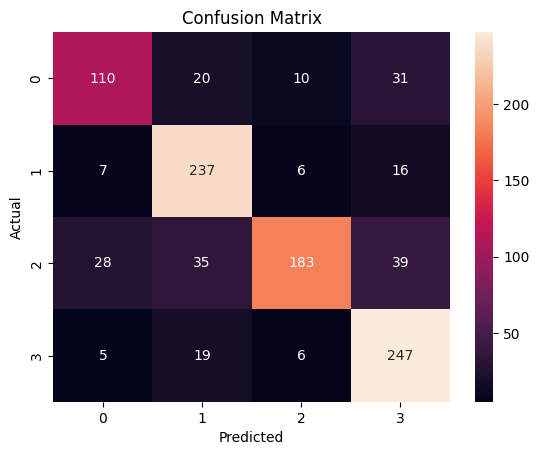

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

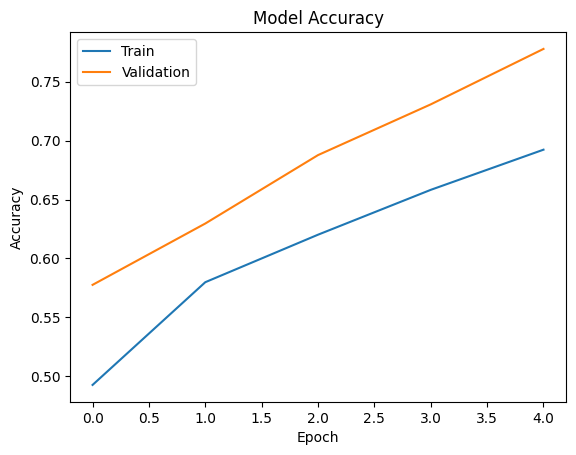

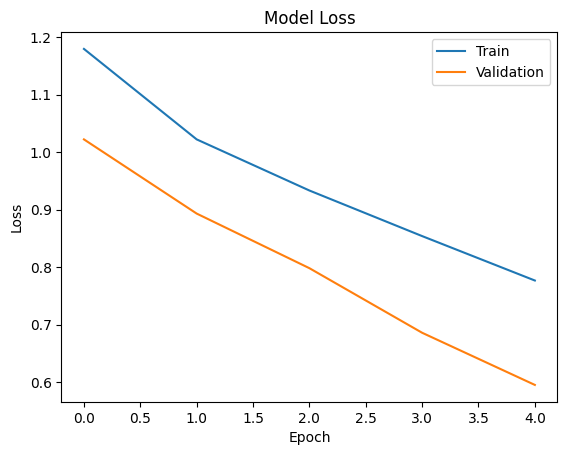

In [65]:

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [66]:
model.save("sentiment_lstm.h5")